# 01 EDA
Use this notebook for exploratory data analysis only. Move reusable logic into `src/`.

In [24]:
import pandas as pd
import os
os.getcwd()
df = pd.read_csv("./data/processed/train.csv")
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# 01 — Exploratory Data Analysis (EDA)

**Goal:** Understand the dataset *before* touching any model.

EDA answers four questions:
1. What does the data look like? (shape, types, samples)
2. Is the target balanced?
3. Are there missing values or data quality issues?
4. Which features look informative?

> **Rule:** No model code here. Findings drive decisions in `02_feature_experiments.ipynb` and ultimately in `src/features/preprocess.py`.

In [26]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes.value_counts())
print("\nAll columns:", df.columns.tolist())
df.describe().T.round(2)

Shape: (569, 31)

Column dtypes:
float64    30
int64       1
Name: count, dtype: int64

All columns: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


## Step 2 — Target Distribution

For a classifier the first question is always: **is the target balanced?**

Imbalanced targets make accuracy misleading — always check class proportions first.

Class counts:
 target
1    357
0    212

Class %:
 target
1    62.7
0    37.3


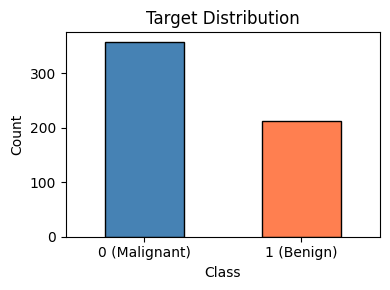

In [27]:
import matplotlib.pyplot as plt

counts = df['target'].value_counts()
pct    = df['target'].value_counts(normalize=True).mul(100).round(1)

print("Class counts:\n", counts.to_string())
print("\nClass %:\n", pct.to_string())

fig, ax = plt.subplots(figsize=(4, 3))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Target Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['0 (Malignant)', '1 (Benign)'], rotation=0)
plt.tight_layout()
plt.show()

In [28]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

report = (
    pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
    .query('missing_count > 0')
)

if report.empty:
    print("No missing values found.")
    print("The imputers in src/features/preprocess.py act as a safety net for future data.")
else:
    print(report.sort_values('missing_%', ascending=False))

No missing values found.
The imputers in src/features/preprocess.py act as a safety net for future data.


Numeric features    : 30
Categorical features: 0


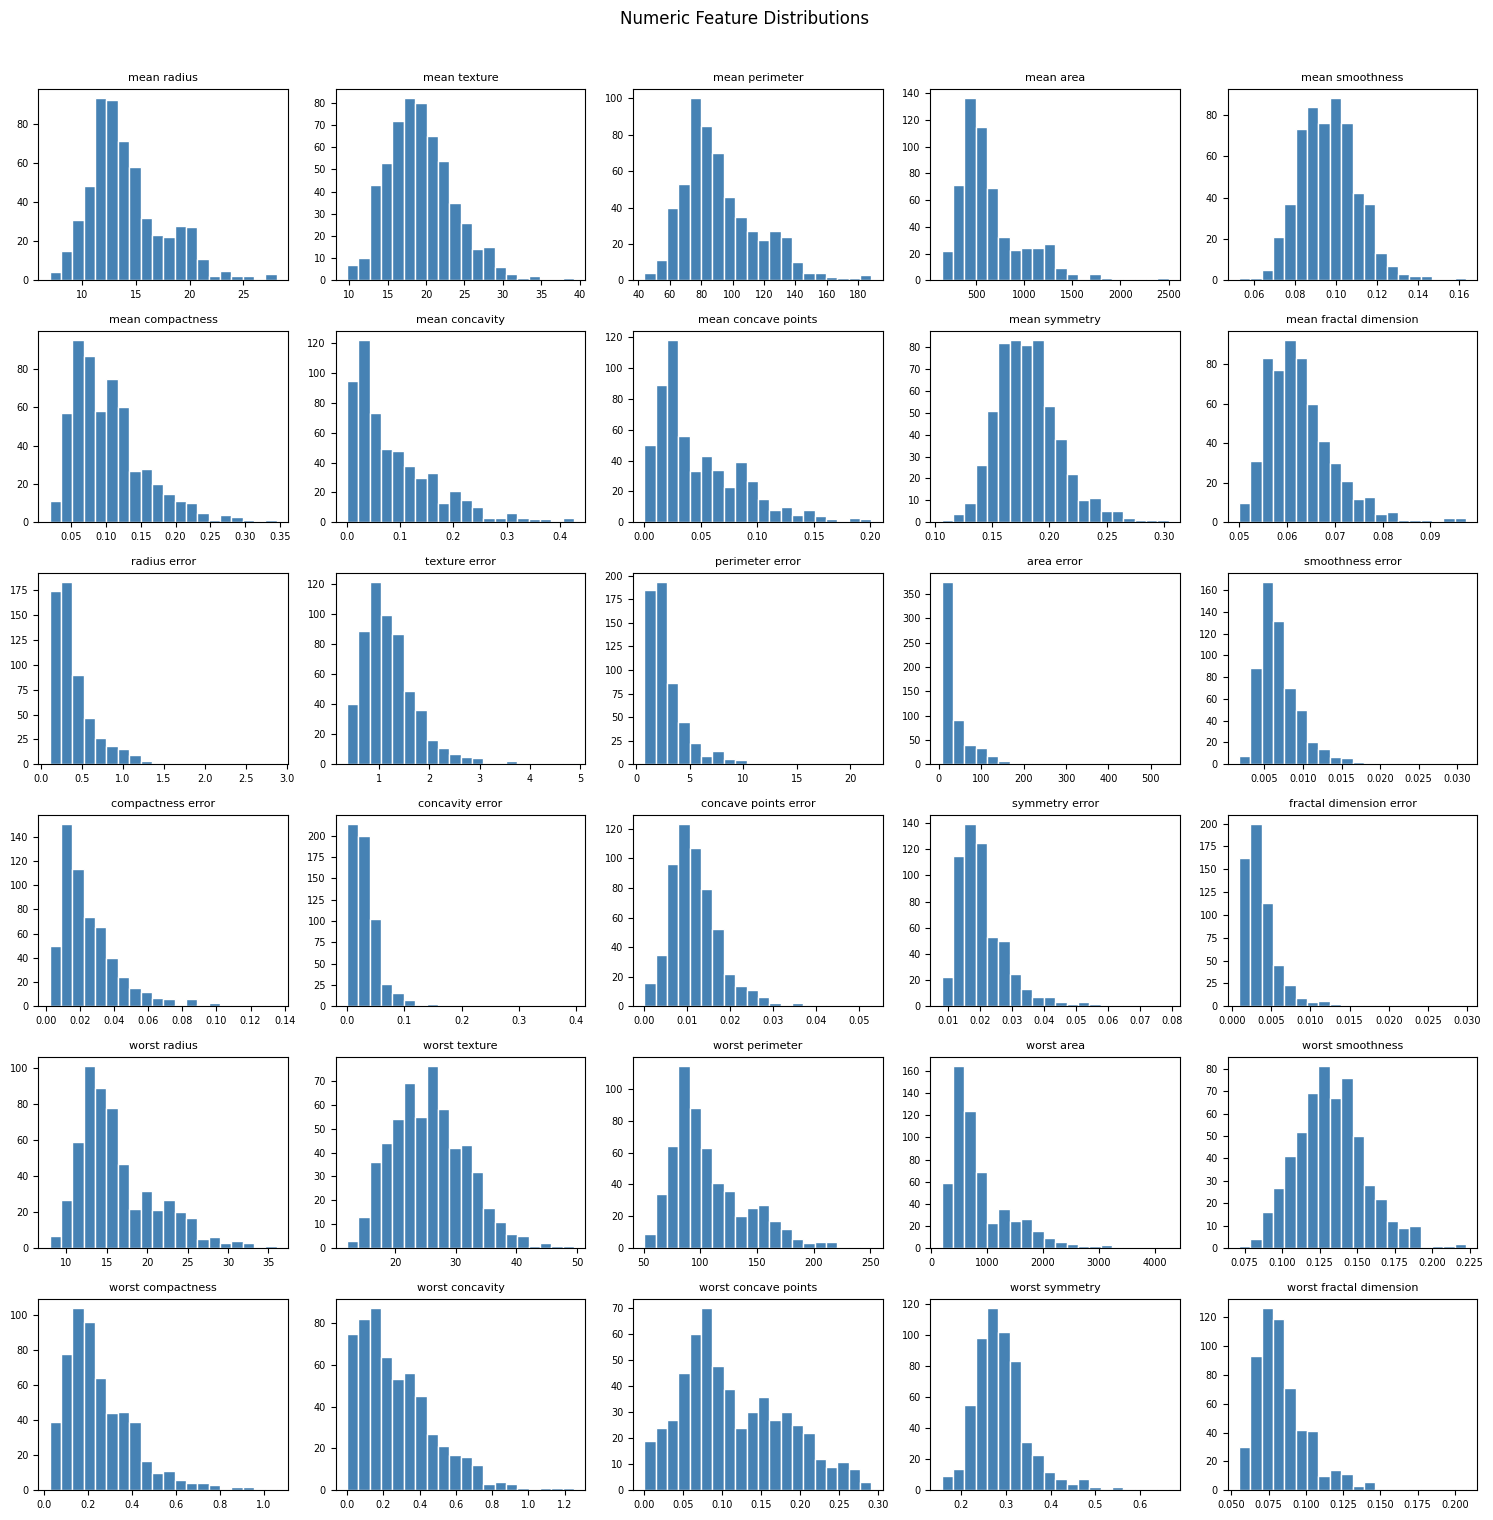


Observation: features have very different scales.
This is why scale_numeric: true is set in configs/features/default.yaml


In [29]:
feature_cols  = [c for c in df.columns if c != 'target']
numeric_cols  = df[feature_cols].select_dtypes(include='number').columns.tolist()
cat_cols      = [c for c in feature_cols if c not in numeric_cols]

print(f"Numeric features    : {len(numeric_cols)}")
print(f"Categorical features: {len(cat_cols)}")

# Histogram grid
n_cols = 5
n_rows = -(-len(numeric_cols) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

print("\nObservation: features have very different scales.")
print("This is why scale_numeric: true is set in configs/features/default.yaml")

## Step 5 — Correlation Analysis

High inter-feature correlation means redundant information. This informs whether to add columns to `drop_columns` in `configs/features/default.yaml`.

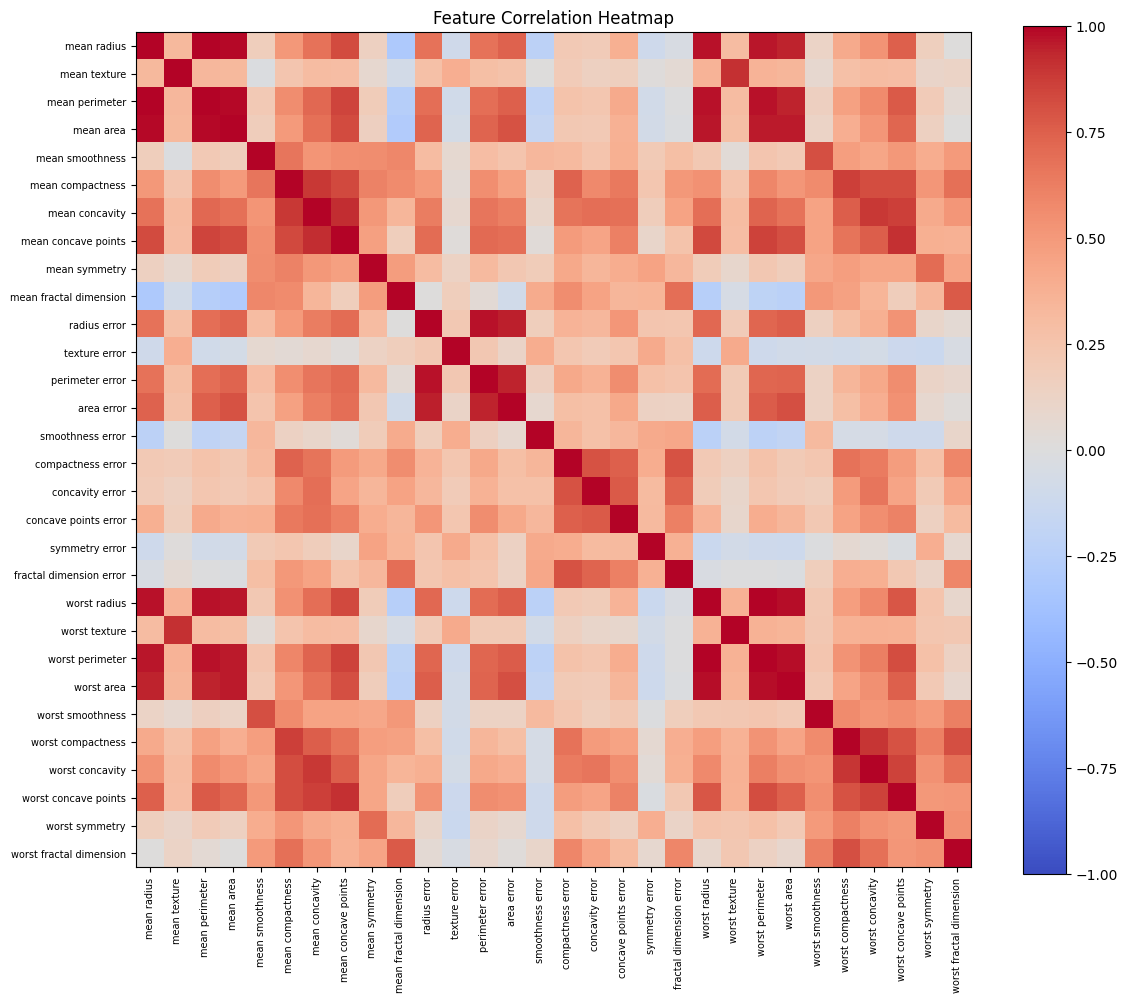

Feature pairs with |correlation| >= 0.9:
          feature_1            feature_2     corr
        mean radius       mean perimeter 0.997855
       worst radius      worst perimeter 0.993708
        mean radius            mean area 0.987357
     mean perimeter            mean area 0.986507
       worst radius           worst area 0.984015
    worst perimeter           worst area 0.977578
       radius error      perimeter error 0.972794
     mean perimeter      worst perimeter 0.970387
        mean radius         worst radius 0.969539
     mean perimeter         worst radius 0.969476
        mean radius      worst perimeter 0.965137
          mean area         worst radius 0.962746
          mean area           worst area 0.959213
          mean area      worst perimeter 0.959120
       radius error           area error 0.951830
     mean perimeter           worst area 0.941550
        mean radius           worst area 0.941082
    perimeter error           area error 0.937655
     mean

In [30]:
import numpy as np

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, fontsize=7)
ax.set_yticklabels(numeric_cols, fontsize=7)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print highly correlated pairs
threshold = 0.9
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack().reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
    .query('abs(corr) >= @threshold')
    .sort_values('corr', ascending=False)
)
print(f"Feature pairs with |correlation| >= {threshold}:")
print(high_corr.to_string(index=False))

## Step 6 — EDA Summary & Decisions

Map every finding to an action in the repo:

| Finding | Decision | Where in repo |
|---|---|---|
| No missing values | Imputers are a safety net | `src/features/preprocess.py` |
| Features on very different scales | `scale_numeric: true` | `configs/features/default.yaml` |
| No categorical columns (this dataset) | OHE branch ready for future data | `src/features/preprocess.py` |
| Highly correlated feature pairs | Candidates for `drop_columns` | `configs/features/default.yaml` |
| Slightly imbalanced target | Use `roc_auc`, not just accuracy | `src/eval/metrics.py` |

> **Key principle:** Every EDA decision must be traceable to a line of config or code — not buried in a notebook.